## Importing files and loading

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

USERS_DATA_PATH = r"C:\Users\thesh\Downloads\users_data.csv"
CARDS_DATA_PATH = r"C:\Users\thesh\Downloads\cards_data.csv"
TRANSACTIONS_DATA_PATH = r"C:\Users\thesh\Downloads\transactions_data.csv"

try:
    df_users = pd.read_csv(USERS_DATA_PATH)
    df_cards = pd.read_csv(CARDS_DATA_PATH)
    df_trans = pd.read_csv(TRANSACTIONS_DATA_PATH)
    print(" Data successfully loaded!")
except FileNotFoundError as e:
    print(
        f"Check your paths.\nDetails: {e}"
    )

 Data successfully loaded!


## Data check and clean

In [18]:
# 1-2. Continuous
df_trans["amount"] = (
    df_trans["amount"].astype(str).str.replace("$", "", regex=False)
)
df_trans["amount"] = pd.to_numeric(df_trans["amount"], errors="coerce")

df_cards["credit_limit"] = (
    df_cards["credit_limit"].astype(str).str.replace("$", "", regex=False)
)
df_cards["credit_limit"] = pd.to_numeric(
    df_cards["credit_limit"], errors="coerce"
)

num_cols = ["current_age", "retirement_age", "yearly_income", "total_debt", "credit_score"]
for col in num_cols:
    if col in df_users.columns:
        df_users[col] = (
            df_users[col].astype(str).str.replace("$", "", regex=False)
        )
        df_users[col] = pd.to_numeric(df_users[col], errors="coerce")

# 3. duplicates
df_trans.drop_duplicates(inplace=True)
df_users.drop_duplicates(inplace=True)
df_cards.drop_duplicates(inplace=True)

# 4. Missing Values
df_users.fillna(df_users.mean(numeric_only=True), inplace=True)
df_cards.fillna(df_cards.mean(numeric_only=True), inplace=True)
df_trans.fillna(df_trans.mean(numeric_only=True), inplace=True)

# 5. use_chip
df_trans["use_chip"] = df_trans["use_chip"].astype(str).str.lower().str.strip()
df_trans["use_chip"] = df_trans["use_chip"].replace(
    {"swipe transaction": "swipe", "chip transaction": "chip", "online transaction": "online"}
)

# 6-7. Cities & States
df_trans["merchant_city"] = (
    df_trans["merchant_city"].astype(str).str.strip().str.title()
)
df_trans["merchant_state"] = (
    df_trans["merchant_state"].astype(str).str.strip().str.upper()
)

# 8. 5-digit Zipcode
df_trans["zip"] = (
    df_trans["zip"].fillna(0).astype(int).astype(str).str.zfill(5)
)

print("No isses!")

No isses!


## Customer card profile

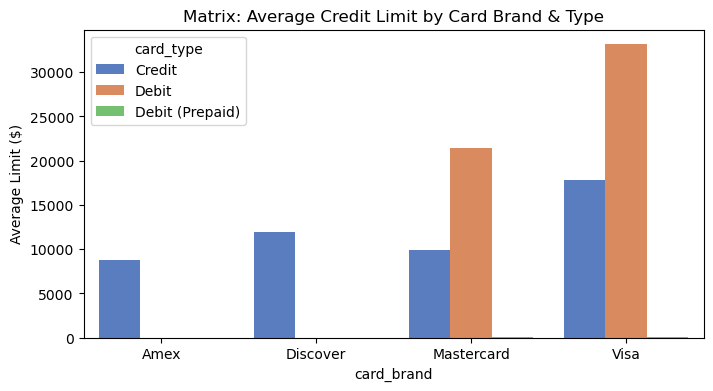

In [19]:
# Card Profiles grouping
card_profile = (
    df_cards.groupby(["card_brand", "card_type"], observed=False)[
        "credit_limit"
    ]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 4))
sns.barplot(
    data=card_profile,
    x="card_brand",
    y="credit_limit",
    hue="card_type",
    palette="muted",
)
plt.title("Matrix: Average Credit Limit by Card Brand & Type")
plt.ylabel("Average Limit ($)")
plt.show()


In [ ]:
#premium tier brands allocate higher threshold margins on Credit lines vs Debit variants.

## Transactions

Transaction Timeline window: 2010-01-01 04:45:00 to 2012-10-29 12:55:00
Top overall Spender (Client ID): 708
Max transaction amount: $6820.2 | Min: $-500.0


C:\Users\thesh\AppData\Local\Temp\ipykernel_21568\2448212744.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_trans, x="use_chip", y="amount", palette="Set2")


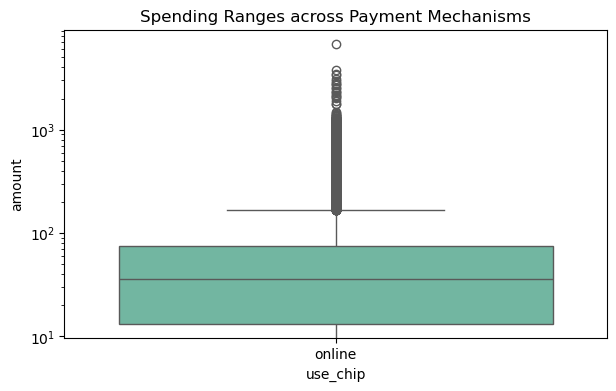

In [21]:
# Timeframe
df_trans["date"] = pd.to_datetime(df_trans["date"])
print("Transaction Timeline window:", df_trans["date"].min(), "to", df_trans["date"].max())

# Max spend customer
top_customer = df_trans.groupby("client_id")["amount"].sum().idxmax()
print(f"Top overall Spender (Client ID): {top_customer}")
print(f"Max transaction amount: ${df_trans['amount'].max()} | Min: ${df_trans['amount'].min()}")

# Outlier
plt.figure(figsize=(7, 4))
sns.boxplot(data=df_trans, x="use_chip", y="amount", palette="Set2")
plt.yscale("log")
plt.title("Spending Ranges across Payment Mechanisms")
plt.show()

## Customer's Spend vs Credit health

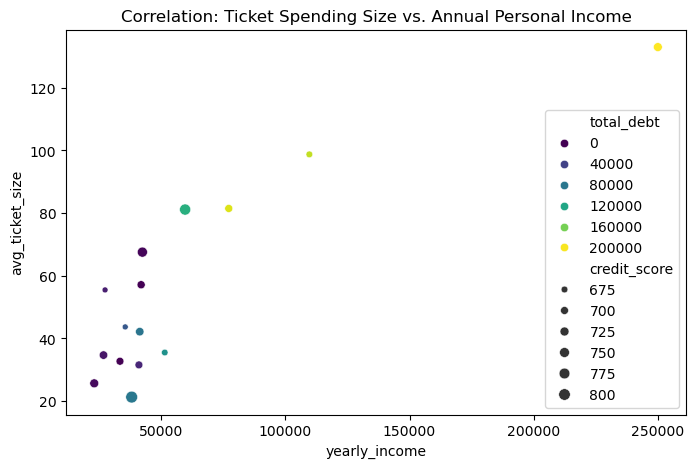

In [28]:
# Aggregation
user_spend = (
    df_trans.groupby("client_id")
    .agg(
        total_spend=("amount", "sum"),
        avg_ticket_size=("amount", "mean"),
        trans_count=("amount", "count"),
    )
    .reset_index()
)

# Merging profiles
credit_health = pd.merge(
    user_spend, df_users, left_on="client_id", right_on="id"
)

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=credit_health,
    x="yearly_income",
    y="avg_ticket_size",
    hue="total_debt",
    size="credit_score",
    palette="viridis",
)
plt.title("Correlation: Ticket Spending Size vs. Annual Personal Income")
plt.show()

## Age portfolio

Share of customers in each age band:
age_band
Senior (50+)       48.0
Mid-Age (30-50)    40.0
Young (<30)        12.0
Name: proportion, dtype: float64

Average Credit Limit by Age Band:
          age_band  credit_limit
0      Young (<30)  35299.333333
1  Mid-Age (30-50)  13683.750000
2     Senior (50+)  22994.711111


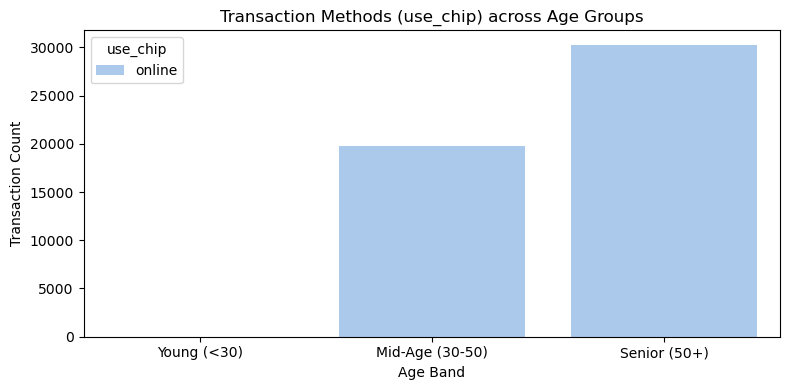

In [29]:
# 1. Cleaning the 'credit_limit' column for numeric
df_cards["credit_limit"] = (
    df_cards["credit_limit"].astype(str).str.replace("$", "", regex=False)
)
df_cards["credit_limit"] = pd.to_numeric(
    df_cards["credit_limit"], errors="coerce"
)

# 2. Calculating customer age (using 2026)
df_users["age"] = 2026 - df_users["birth_year"]

# 3. age bands
df_users["age_band"] = pd.cut(
    df_users["age"],
    bins=[0, 30, 50, 110],
    labels=["Young (<30)", "Mid-Age (30-50)", "Senior (50+)"],
)

# 4. share of customers in each age band
print("Share of customers in each age band:")
print(df_users["age_band"].value_counts(normalize=True) * 100)

# 5. Merging cards with users to calculate average credit limit per band
df_cards_age = pd.merge(df_cards, df_users, left_on="client_id", right_on="id")
avg_limit = (
    df_cards_age.groupby("age_band", observed=False)["credit_limit"]
    .mean()
    .reset_index()
)

print("\nAverage Credit Limit by Age Band:")
print(avg_limit)

# 6. check chip/online usage habits
df_trans_age = pd.merge(df_trans, df_users, left_on="client_id", right_on="id")

# 7. chart
plt.figure(figsize=(8, 4))
sns.countplot(data=df_trans_age, x="age_band", hue="use_chip", palette="pastel")
plt.title("Transaction Methods (use_chip) across Age Groups")
plt.xlabel("Age Band")
plt.ylabel("Transaction Count")
plt.tight_layout()
plt.show()

### Gender Analysis

Average transactional baseline ticket split by gender:
 gender
Female    51.678074
Male      51.573033
Name: amount, dtype: float64


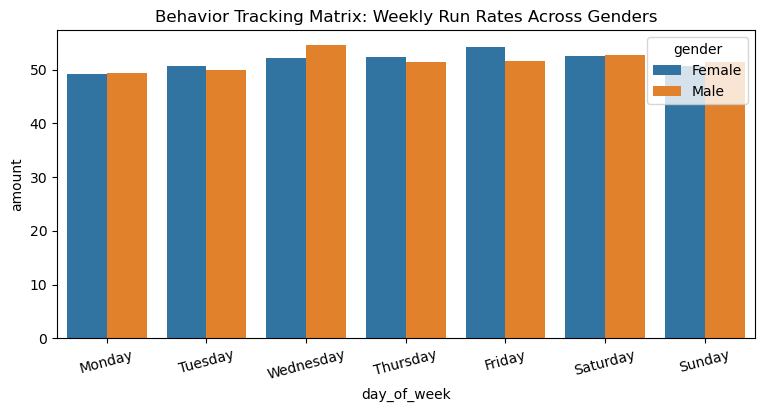

In [31]:
df_gender = pd.merge(df_trans, df_users, left_on="client_id", right_on="id")
df_gender["day_of_week"] = df_gender["date"].dt.day_name()

print("Average transactional baseline ticket split by gender:\n", df_gender.groupby("gender")["amount"].mean())

plt.figure(figsize=(9, 4))
sns.barplot(
    data=df_gender,
    x="day_of_week",
    y="amount",
    hue="gender",
    errorbar=None,
    order=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"],
)
plt.title("Behavior Tracking Matrix: Weekly Run Rates Across Genders")
plt.xticks(rotation=15)
plt.show()

# Target weekend spikes via customized alerts